# Comparaison des modèles entraînés


Ce notebook mélange deux types de mesures, clairement identifiées dans chaque section :

| Source | Mode | ε | Politique | Signification |
|---|---|---|---|---|
| `training_curve.csv` | **TRAINING** | ε-greedy (1.0 → ε_end) | en cours d'apprentissage | Reward par épisode pendant l'entraînement, inclut l'exploration |
| `metrics.csv` (par run) | **INFERENCE** | 0 (greedy) | frozen aux checkpoints | Eval pendant l'entraînement : politique figée à 1k/10k/50k eps, N parties vs random |
| `summary.csv` (global) | **INFERENCE** | 0 (greedy) | re-évaluée a posteriori | Produit par `scripts/evaluate_all.py` — modèles sauvés rechargés, avec player-swap P0/P1 |

**Toutes les métriques de performance finale (reward, winrate, temps d'action, truncation) viennent de l'INFERENCE.** Les courbes d'apprentissage (section 1) viennent du TRAINING pour visualiser la dynamique d'apprentissage.

## Contenu

1. **[TRAINING]** Courbes d'apprentissage : reward par épisode (moyenne glissante)
2. **[INFERENCE]** Reward moyen au dernier checkpoint par agent × env
3. **[INFERENCE]** Temps d'action (ms/coup) + steps/partie
4. **[INFERENCE]** Player-swap : winrate quand l'agent est P0 vs P1
5. **[INFERENCE]** Reward aux checkpoints 1k / 10k / 50k (métrique prof)
6. **[INFERENCE]** Taux de terminaison : parties vraiment finies vs tronquées à `max_steps=10000`
7. Hyperparamètres de chaque run

**Prérequis** : `uv run scripts/evaluate_all.py --num-games 100` a été exécuté.


In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import yaml

ROOT = Path("..").resolve() if Path("..").resolve().name == "projet" else Path(".").resolve()
if ROOT.name != "projet":
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RESULTS_DIR = ROOT / "results"
SUMMARY_CSV = RESULTS_DIR / "summary.csv"

ADVERSARIAL_ENVS = {"tictactoe", "bobail"}
AGENT_ORDER = ["random", "tabular_q", "dqn", "ddqn", "ddqn_er", "ddqn_per"]
ENV_ORDER = ["line_world", "grid_world", "tictactoe", "bobail"]

print("ROOT =", ROOT)
print("Summary exists:", SUMMARY_CSV.exists())


ROOT = /Users/brandontchakaniyungeko/ESGI-dev/5IABD/T2/deep_reinforcement_learning/projet
Summary exists: True


In [2]:
def iter_runs(results_dir: Path):
    """Yield (env, agent, run_dir) for every config.yaml found."""
    for env_dir in sorted(results_dir.iterdir()):
        if not env_dir.is_dir():
            continue
        for agent_dir in sorted(env_dir.iterdir()):
            if not agent_dir.is_dir():
                continue
            for run_dir in sorted(agent_dir.iterdir()):
                if (run_dir / "config.yaml").exists():
                    yield env_dir.name, agent_dir.name, run_dir

def load_curve(run_dir: Path, rolling: int = 100) -> pd.DataFrame:
    path = run_dir / "training_curve.csv"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df["reward_smooth"] = df["reward"].rolling(rolling, min_periods=1).mean()
    return df

def load_config(run_dir: Path) -> dict:
    with open(run_dir / "config.yaml") as f:
        return yaml.safe_load(f)

summary = pd.read_csv(SUMMARY_CSV) if SUMMARY_CSV.exists() else pd.DataFrame()
print(f"Summary rows: {len(summary)}")
print(f"Envs : {sorted(summary['env'].unique()) if len(summary) else []}")
print(f"Agents: {sorted(summary['agent'].unique()) if len(summary) else []}")
summary.head()


Summary rows: 1017
Envs : ['bobail', 'grid_world', 'line_world', 'tictactoe']
Agents: ['ddqn', 'ddqn_er', 'ddqn_per', 'dqn', 'ppo', 'reinforce', 'reinforce_critic', 'reinforce_mean_baseline', 'tabular_q']


,env,agent,run_dir,seed,checkpoint,side,mean_reward,std_reward,mean_steps,std_steps,mean_action_time_ms,std_action_time_ms,win_rate,draw_rate,loss_rate,termination_rate,truncation_rate,num_games
0,bobail,ddqn,results/bobail/ddqn/batch_size64_buffer_capaci...,123,1000,combined,-0.96,NaN,86.13,NaN,0.032373,NaN,0.02,0.0,0.98,1.0,0.0,100
1,bobail,ddqn,results/bobail/ddqn/batch_size64_buffer_capaci...,123,1000,p0,-0.92,0.391918,90.18,89.707456,0.032741,0.006444,0.04,0.0,0.96,1.0,0.0,50
2,bobail,ddqn,results/bobail/ddqn/batch_size64_buffer_capaci...,123,1000,p1,-1.00,0.000000,82.08,75.958894,0.032005,0.003754,0.00,0.0,1.00,1.0,0.0,50
3,bobail,ddqn,results/bobail/ddqn/batch_size64_buffer_capaci...,123,10000,combined,-0.84,NaN,259.87,NaN,0.033372,NaN,0.08,0.0,0.92,1.0,0.0,100
4,bobail,ddqn,results/bobail/ddqn/batch_size64_buffer_capaci...,123,10000,p0,-0.84,0.542586,164.66,118.951017,0.032325,0.002751,0.08,0.0,0.92,1.0,0.0,50


## 1. [TRAINING] Courbes d'apprentissage

**Source : `training_curve.csv`** — reward collectée **pendant** l'entraînement, avec ε-greedy (exploration active). Ce n'est PAS la performance de la politique greedy — juste la dynamique d'apprentissage.

Une courbe par agent, une sous-figure par environnement. Moyenne glissante window=100.


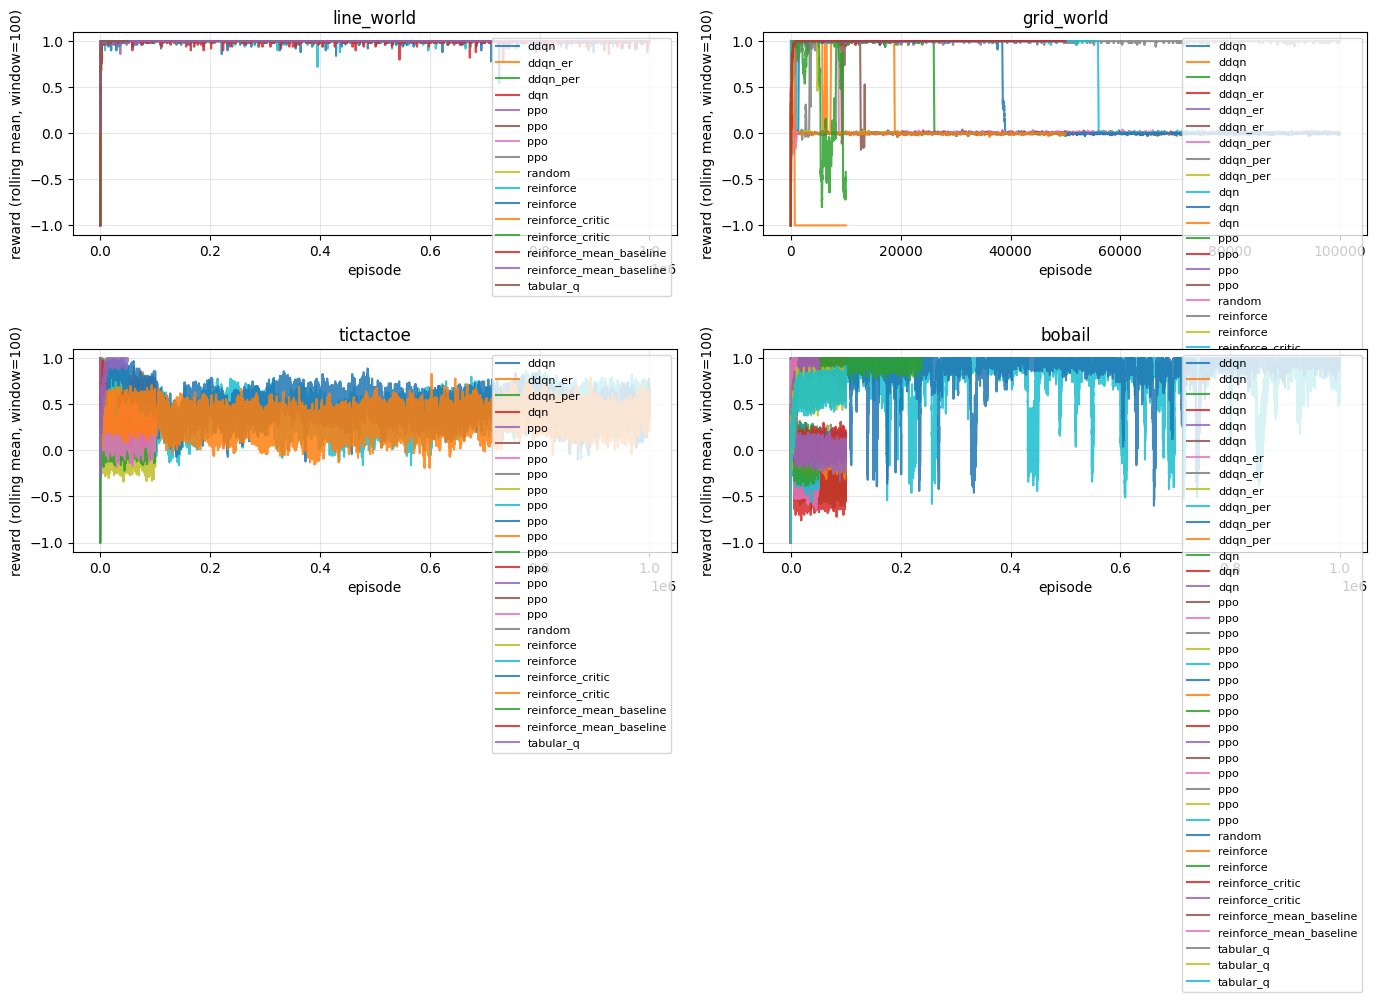

In [3]:
runs = list(iter_runs(RESULTS_DIR))
envs_found = sorted({e for e, _, _ in runs}, key=lambda x: ENV_ORDER.index(x) if x in ENV_ORDER else 99)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, env in zip(axes, envs_found):
    for env_name, agent, run_dir in runs:
        if env_name != env:
            continue
        df = load_curve(run_dir)
        if df.empty:
            continue
        ax.plot(df["episode"], df["reward_smooth"], label=agent, alpha=0.85)
    ax.set_title(env)
    ax.set_xlabel("episode")
    ax.set_ylabel("reward (rolling mean, window=100)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=8)

for ax in axes[len(envs_found):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## 2. [INFERENCE] Performance finale par environnement

**Source : `summary.csv`** — politique figée, greedy (ε=0), modèle rechargé depuis `model_*.pt`, re-évalué sur N parties.

Reward moyen au dernier checkpoint de chaque run. Pour les envs adversariales, on utilise la reward **combinée** (moyenne pondérée P0 + P1).

> **Note sur la reward adversariale** : reward ∈ {−1, 0, +1} par partie. `mean_reward = win_rate − loss_rate` exactement. La relation `mean_reward = 2×win_rate − 1` n'est valable **que** si draw_rate = 0 ET truncation_rate = 0. Voir sections 4 et 6.


Mean reward at final checkpoint:


env,line_world,grid_world,tictactoe,bobail
agent,,,,
tabular_q,1.0,1.0,0.60,0.32
dqn,1.0,0.0,0.09,-0.50
ddqn,1.0,0.0,0.06,-0.80
ddqn_er,1.0,0.0,0.00,-0.68
ddqn_per,1.0,0.0,0.09,-0.48


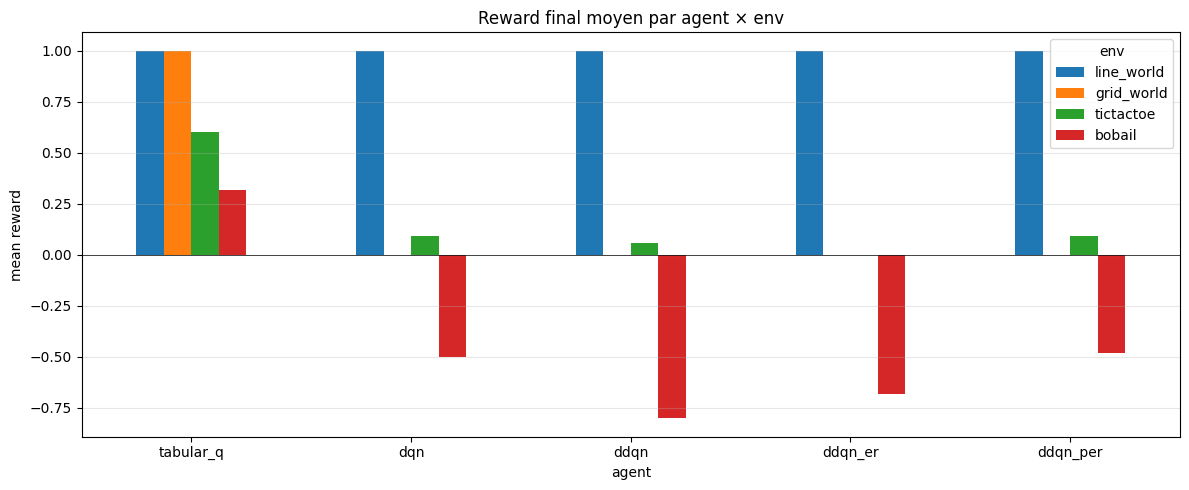

In [4]:
def side_for(env):
    return "combined" if env in ADVERSARIAL_ENVS else "single"

def final_rows(df: pd.DataFrame) -> pd.DataFrame:
    df = df[df["side"].isin(["combined", "single"])].copy()
    idx = df.groupby(["env", "agent"])["checkpoint"].idxmax()
    return df.loc[idx].reset_index(drop=True)

final = final_rows(summary)
pivot_reward = final.pivot(index="agent", columns="env", values="mean_reward")
pivot_reward = pivot_reward.reindex(index=[a for a in AGENT_ORDER if a in pivot_reward.index],
                                     columns=[e for e in ENV_ORDER if e in pivot_reward.columns])
print("Mean reward at final checkpoint:")
display(pivot_reward.round(3))

fig, ax = plt.subplots(figsize=(12, 5))
pivot_reward.plot(kind="bar", ax=ax)
ax.set_title("Reward final moyen par agent × env")
ax.set_ylabel("mean reward")
ax.axhline(0, color="k", lw=0.5)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 3. [INFERENCE] Temps d'action + steps par partie

**Source : `summary.csv` (inference)**.

- `mean_action_time_ms` : temps CPU moyen pour que l'agent choisisse une action en mode greedy (ε=0).
- `mean_steps` : longueur moyenne d'une partie d'évaluation. Une valeur proche de 10000 indique une **troncation** (cf. section 6).


In [5]:
pivot_time = final.pivot(index="agent", columns="env", values="mean_action_time_ms")
pivot_time = pivot_time.reindex(index=[a for a in AGENT_ORDER if a in pivot_time.index],
                                 columns=[e for e in ENV_ORDER if e in pivot_time.columns])
print("Mean action time (ms):")
display(pivot_time.round(3))

pivot_steps = final.pivot(index="agent", columns="env", values="mean_steps")
pivot_steps = pivot_steps.reindex(index=[a for a in AGENT_ORDER if a in pivot_steps.index],
                                   columns=[e for e in ENV_ORDER if e in pivot_steps.columns])
print("\nMean steps per game:")
display(pivot_steps.round(1))


Mean action time (ms):


env,line_world,grid_world,tictactoe,bobail
agent,,,,
tabular_q,0.001,0.001,0.002,0.004
dqn,0.024,0.023,0.030,0.037
ddqn,0.024,0.023,0.032,0.034
ddqn_er,0.023,0.024,0.030,0.033
ddqn_per,0.025,0.024,0.030,0.032



Mean steps per game:


env,line_world,grid_world,tictactoe,bobail
agent,,,,
tabular_q,2.0,8.0,6.1,11.4
dqn,2.0,10000.0,8.4,432.2
ddqn,2.0,10000.0,8.3,309.1
ddqn_er,2.0,10000.0,8.5,466.5
ddqn_per,2.0,10000.0,8.4,362.9


## 4. [INFERENCE] Analyse player-swap (envs adversariales)

**Source : `summary.csv`, rows side ∈ {p0, p1}** — produit par `evaluator.evaluate_both_sides()` qui split `num_games` en deux : moitié des parties avec agent=P0 (joue en premier), moitié avec agent=P1 (joue en second).

Winrate vs random opponent, séparément P0 et P1. Un écart important = le modèle dépend du first-move advantage et n'a pas appris une politique robuste aux deux positions.

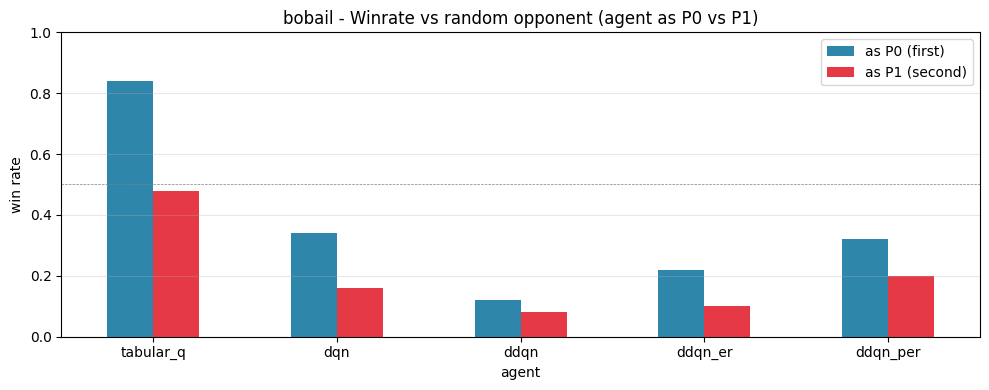


bobail - winrate table:


,as P0 (first),as P1 (second)
agent,,
tabular_q,0.84,0.48
dqn,0.34,0.16
ddqn,0.12,0.08
ddqn_er,0.22,0.10
ddqn_per,0.32,0.20


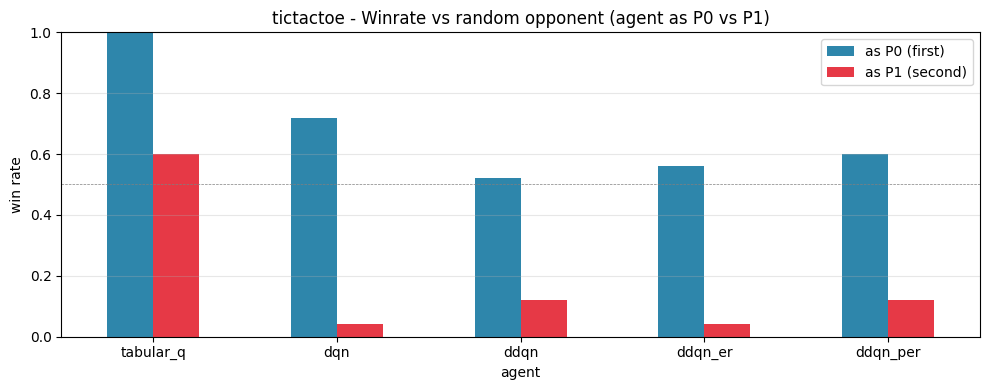


tictactoe - winrate table:


,as P0 (first),as P1 (second)
agent,,
tabular_q,1.00,0.60
dqn,0.72,0.04
ddqn,0.52,0.12
ddqn_er,0.56,0.04
ddqn_per,0.60,0.12


In [6]:
adv = summary[summary["env"].isin(ADVERSARIAL_ENVS) & summary["side"].isin(["p0", "p1"])].copy()
if len(adv):
    idx = adv.groupby(["env", "agent", "side"])["checkpoint"].idxmax()
    adv_final = adv.loc[idx].reset_index(drop=True)

    for env in sorted(adv_final["env"].unique()):
        sub = adv_final[adv_final["env"] == env]
        piv = sub.pivot(index="agent", columns="side", values="win_rate")
        piv = piv.reindex([a for a in AGENT_ORDER if a in piv.index])
        piv.columns = ["as P0 (first)", "as P1 (second)"]

        fig, ax = plt.subplots(figsize=(10, 4))
        piv.plot(kind="bar", ax=ax, color=["#2E86AB", "#E63946"])
        ax.set_title(f"{env} - Winrate vs random opponent (agent as P0 vs P1)")
        ax.set_ylabel("win rate")
        ax.set_ylim(0, 1)
        ax.axhline(0.5, color="gray", ls="--", lw=0.5)
        ax.grid(axis="y", alpha=0.3)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

        print(f"\n{env} - winrate table:")
        display(piv.round(3))
else:
    print("No adversarial P0/P1 data in summary. Re-run scripts/evaluate_all.py")


## 5. [INFERENCE] Métriques aux checkpoints (1k / 10k / 50k)

**Source : `summary.csv`**. Format demandé par le prof : score moyen **de la politique figée** évaluée après N parties d'entraînement.


In [7]:
ckpt_data = summary[summary["side"].isin(["combined", "single"])].copy()
for env in [e for e in ENV_ORDER if e in ckpt_data["env"].unique()]:
    sub = ckpt_data[ckpt_data["env"] == env]
    piv = sub.pivot_table(index="agent", columns="checkpoint",
                           values="mean_reward", aggfunc="mean")
    piv = piv.reindex([a for a in AGENT_ORDER if a in piv.index])
    print(f"\n=== {env} ===")
    display(piv.round(3))



=== line_world ===


checkpoint,1000,5000,10000,50000,100000,250000,1000000
agent,,,,,,,
tabular_q,1.0,NaN,1.0,1.0,NaN,NaN,NaN
dqn,1.0,NaN,1.0,1.0,NaN,NaN,NaN
ddqn,1.0,NaN,1.0,1.0,NaN,NaN,NaN
ddqn_er,1.0,NaN,1.0,1.0,NaN,NaN,NaN
ddqn_per,1.0,NaN,1.0,1.0,NaN,NaN,NaN



=== grid_world ===


checkpoint,500,1000,2000,3000,4000,5000,10000,20000,50000,100000,250000
agent,,,,,,,,,,,
tabular_q,NaN,1.000,NaN,NaN,NaN,NaN,1.000,NaN,1.000,NaN,NaN
dqn,NaN,0.000,NaN,NaN,NaN,NaN,0.333,NaN,0.333,0.0,NaN
ddqn,NaN,0.667,NaN,NaN,NaN,NaN,1.000,NaN,0.000,0.0,NaN
ddqn_er,NaN,0.333,NaN,NaN,NaN,NaN,0.333,NaN,0.000,0.0,NaN
ddqn_per,NaN,0.333,NaN,NaN,NaN,NaN,0.333,NaN,0.333,0.5,NaN



=== tictactoe ===


checkpoint,500,1000,2000,3000,4000,5000,10000,20000,30000,40000,50000,70000,100000,1000000
agent,,,,,,,,,,,,,,
tabular_q,NaN,0.36,NaN,NaN,NaN,NaN,0.42,NaN,NaN,NaN,0.60,NaN,NaN,NaN
dqn,NaN,-0.06,NaN,NaN,NaN,NaN,-0.09,NaN,NaN,NaN,0.09,NaN,NaN,NaN
ddqn,NaN,-0.13,NaN,NaN,NaN,NaN,0.08,NaN,NaN,NaN,0.06,NaN,NaN,NaN
ddqn_er,NaN,0.29,NaN,NaN,NaN,NaN,0.25,NaN,NaN,NaN,0.00,NaN,NaN,NaN
ddqn_per,NaN,0.50,NaN,NaN,NaN,NaN,0.13,NaN,NaN,NaN,0.09,NaN,NaN,NaN



=== bobail ===


checkpoint,10,50,100,500,700,1000,2000,3000,4000,5000,10000,20000,40000,50000,100000,200000
agent,,,,,,,,,,,,,,,,
tabular_q,NaN,NaN,NaN,NaN,NaN,0.133,NaN,NaN,NaN,0.313,0.287,NaN,NaN,0.350,0.32,NaN
dqn,NaN,NaN,NaN,NaN,NaN,-0.893,NaN,NaN,NaN,NaN,-0.607,NaN,NaN,-0.647,-0.56,NaN
ddqn,NaN,NaN,NaN,NaN,NaN,-0.964,NaN,NaN,NaN,NaN,-0.780,NaN,NaN,-0.600,-0.76,NaN
ddqn_er,NaN,NaN,NaN,NaN,NaN,-0.707,NaN,NaN,NaN,NaN,-0.567,NaN,NaN,-0.533,-0.49,NaN
ddqn_per,NaN,NaN,NaN,NaN,NaN,-0.960,NaN,NaN,NaN,NaN,-0.653,NaN,NaN,-0.667,-0.65,NaN


## 6. [INFERENCE] Taux de terminaison vs troncation

**Source : `summary.csv`** — colonnes `termination_rate` et `truncation_rate`.

- **`termination_rate`** : fraction des parties où l'env a signalé `done=True` dans les 10 000 steps de la boucle d'éval. Ce sont les vraies fins de partie (victoire, défaite, vrai match nul plateau plein).
- **`truncation_rate` = 1 − termination_rate** : fraction des parties où la boucle a atteint `max_steps=10 000` sans que l'env ne termine. L'agent tourne en rond → la politique apprise est défaillante.

**Pourquoi c'est capital** : un `mean_reward=0` peut signifier soit "vrai match nul" soit "partie tronquée". Seul `termination_rate` permet de distinguer les deux. Pour TicTacToe les jeux terminent toujours en ≤9 coups donc `truncation_rate=0` partout. Pour GridWorld/Bobail c'est un vrai diagnostic.


Termination rate at final checkpoint (1.0 = all games ended naturally):


env,line_world,grid_world,tictactoe,bobail
agent,,,,
tabular_q,1.0,1.0,1.0,1.0
dqn,1.0,0.0,1.0,1.0
ddqn,1.0,0.0,1.0,1.0
ddqn_er,1.0,0.0,1.0,1.0
ddqn_per,1.0,0.0,1.0,1.0



Truncation rate (1.0 = all games hit the 10k-step cap = policy is stuck):


env,line_world,grid_world,tictactoe,bobail
agent,,,,
tabular_q,0.0,0.0,0.0,0.0
dqn,0.0,1.0,0.0,0.0
ddqn,0.0,1.0,0.0,0.0
ddqn_er,0.0,1.0,0.0,0.0
ddqn_per,0.0,1.0,0.0,0.0


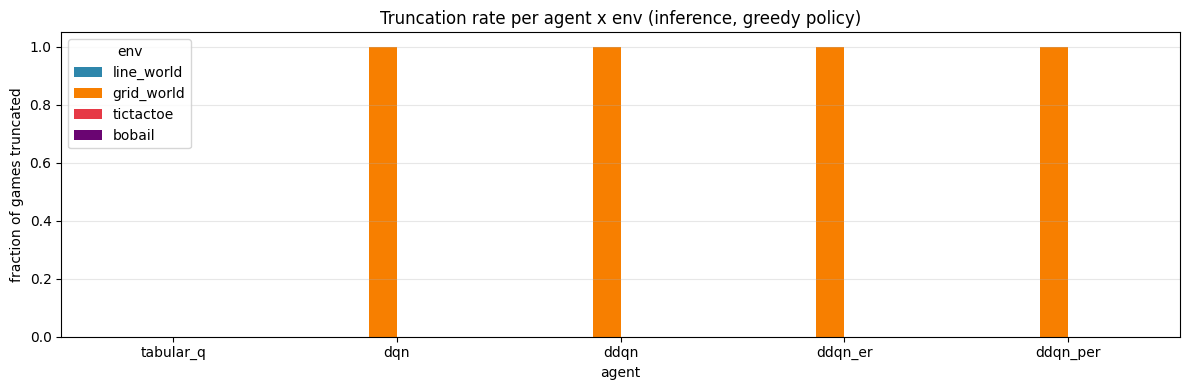

In [8]:
trunc_data = summary[summary["side"].isin(["combined", "single"])].copy()
idx = trunc_data.groupby(["env", "agent"])["checkpoint"].idxmax()
trunc_final = trunc_data.loc[idx].reset_index(drop=True)

piv_term = trunc_final.pivot(index="agent", columns="env", values="termination_rate")
piv_term = piv_term.reindex(index=[a for a in AGENT_ORDER if a in piv_term.index],
                             columns=[e for e in ENV_ORDER if e in piv_term.columns])
print("Termination rate at final checkpoint (1.0 = all games ended naturally):")
display(piv_term.round(3))

piv_trunc = trunc_final.pivot(index="agent", columns="env", values="truncation_rate")
piv_trunc = piv_trunc.reindex(index=[a for a in AGENT_ORDER if a in piv_trunc.index],
                               columns=[e for e in ENV_ORDER if e in piv_trunc.columns])
print("\nTruncation rate (1.0 = all games hit the 10k-step cap = policy is stuck):")
display(piv_trunc.round(3))

fig, ax = plt.subplots(figsize=(12, 4))
piv_trunc.plot(kind="bar", ax=ax, color=["#2E86AB", "#F77F00", "#E63946", "#6A0572"][:len(piv_trunc.columns)])
ax.set_title("Truncation rate per agent x env (inference, greedy policy)")
ax.set_ylabel("fraction of games truncated")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Hyperparamètres de chaque run

Source : `config.yaml` sauvé dans chaque run_dir au moment de l'entraînement.


In [9]:
rows = []
for env, agent, run_dir in runs:
    cfg = load_config(run_dir)
    params = cfg.get("agent_params", {}) or {}
    params_str = ", ".join(f"{k}={v}" for k, v in params.items())
    rows.append({
        "env": env,
        "agent": agent,
        "seed": cfg.get("seed", ""),
        "num_episodes": cfg.get("training", {}).get("num_episodes", ""),
        "max_steps_per_episode (train)": cfg.get("training", {}).get("max_steps_per_episode", ""),
        "opponent": cfg.get("opponent", "-"),
        "agent_params": params_str,
    })

hp = pd.DataFrame(rows).sort_values(["env", "agent"]).reset_index(drop=True)
pd.set_option("display.max_colwidth", 200)
display(hp)


,env,agent,seed,num_episodes,max_steps_per_episode (train),opponent,agent_params
0,bobail,ddqn,42,100000,500,random,"batch_size=64, buffer_capacity=10000, epsilon_decay_steps=100000, epsilon_end=0.05, epsilon_start=1.0, gamma=0.99, hidden_layers=[256, 128], lr=0.0005, target_update_freq=200"
1,bobail,ddqn,123,100000,500,random,"batch_size=64, buffer_capacity=50000, epsilon_decay_steps=100000, epsilon_end=0.05, epsilon_start=1.0, gamma=0.99, hidden_layers=[256, 128], lr=0.0005, target_update_freq=500"
2,bobail,ddqn,42,100000,500,random,"batch_size=64, buffer_capacity=50000, epsilon_decay_steps=100000, epsilon_end=0.05, epsilon_start=1.0, gamma=0.99, hidden_layers=[256, 128], lr=0.0005, target_update_freq=500"
3,bobail,ddqn,456,100000,500,random,"batch_size=64, buffer_capacity=50000, epsilon_decay_steps=100000, epsilon_end=0.05, epsilon_start=1.0, gamma=0.99, hidden_layers=[256, 128], lr=0.0005, target_update_freq=500"
4,bobail,ddqn,123,100000,100,random,"batch_size=64, buffer_capacity=50000, epsilon_decay_steps=80000, epsilon_end=0.05, epsilon_start=1.0, gamma=0.99, hidden_layers=[256, 128], lr=0.0001, target_update_freq=1000"
...,...,...,...,...,...,...,...
132,tictactoe,reinforce_critic,42,100000,20,random,"critic_lr=0.001, gamma=0.99, hidden_layers=[128, 128], lr=0.001"
133,tictactoe,reinforce_mean_baseline,123,10000,20,random,"gamma=0.99, hidden_layers=[128, 128], lr=0.001"
134,tictactoe,reinforce_mean_baseline,42,10000,20,random,"gamma=0.99, hidden_layers=[128, 128], lr=0.001"
135,tictactoe,tabular_q,42,50000,20,random,"epsilon_decay_steps=50000, epsilon_end=0.05, epsilon_start=1.0, gamma=0.99, lr=0.1"
